In [1]:
import os
# Get the name of the current conda environment
env_name = os.getenv("CONDA_DEFAULT_ENV")
print(f"The current Conda environment is: {env_name}")

The current Conda environment is: None


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
from datetime import datetime# Get current time
import io
import tensorflow as tf

# Check if TensorFlow can access a GPU
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

In [4]:
def nse(y_true, y_pred):
    return 1 - (np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2))
import numpy as np

def pbias(y_true, y_pred):
    pbias_value = 100 * np.sum(y_true - y_pred) / np.sum(y_true)
    return float(pbias_value)


def kge(y_true, y_pred):
    # Calculate the Pearson correlation coefficient (r)
    r, _ = pearsonr(y_true, y_pred)
    
    # Calculate the mean of the observed and predicted values
    mu_true = np.mean(y_true)
    mu_pred = np.mean(y_pred)
    
    # Calculate the standard deviation of the observed and predicted values
    sigma_true = np.std(y_true)
    sigma_pred = np.std(y_pred)
    
    # Compute the KGE
    kge_value = 1 - np.sqrt((r - 1)**2 + (sigma_pred / sigma_true - 1)**2 + (mu_pred / mu_true - 1)**2)
    
    return kge_value


In [5]:
valid_rate = 0.3
epochs=256
batch_size= 30
os.chdir('F:\\geodata\\river_runoff_obs')

101/101 [==============================] - 0s 2ms/step - loss: 0.5022 - val_loss: 0.4457
Epoch 109/256
101/101 [==============================] - 0s 2ms/step - loss: 0.5037 - val_loss: 0.4468
Epoch 110/256
101/101 [==============================] - 0s 2ms/step - loss: 0.5023 - val_loss: 0.4463
Epoch 111/256
101/101 [==============================] - 0s 2ms/step - loss: 0.5020 - val_loss: 0.4476
Epoch 112/256
101/101 [==============================] - 0s 2ms/step - loss: 0.5005 - val_loss: 0.4500
Epoch 113/256
101/101 [==============================] - 0s 2ms/step - loss: 0.5025 - val_loss: 0.4471
Epoch 114/256
101/101 [==============================] - 0s 2ms/step - loss: 0.5047 - val_loss: 0.4469
Epoch 115/256
101/101 [==============================] - 0s 2ms/step - loss: 0.5026 - val_loss: 0.4462
Epoch 116/256
101/101 [==============================] - 0s 2ms/step - loss: 0.5019 - val_loss: 0.4454
Epoch 117/256
101/101 [==============================] - 0s 2ms/step - loss: 0.5009 - v

D:\Users\HP\miniconda3\envs\tensorflow-gpu\lib\site-packages\pandas\core\indexes\base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


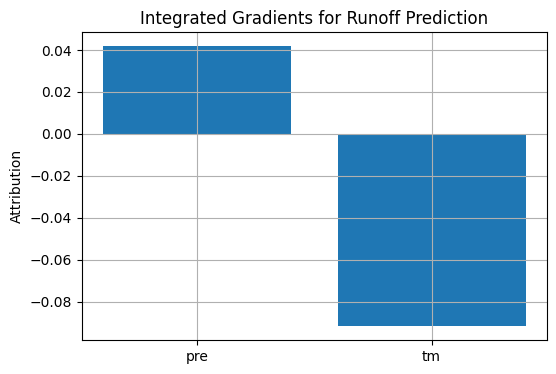

ssp245
Epoch 1/256
101/101 [==============================] - 0s 2ms/step - loss: 0.6062 - val_loss: 0.4535
Epoch 2/256
101/101 [==============================] - 0s 2ms/step - loss: 0.5160 - val_loss: 0.4517
Epoch 3/256
101/101 [==============================] - 0s 2ms/step - loss: 0.5195 - val_loss: 0.4508
Epoch 4/256
101/101 [==============================] - 0s 2ms/step - loss: 0.5105 - val_loss: 0.4595
Epoch 5/256
101/101 [==============================] - 0s 2ms/step - loss: 0.5105 - val_loss: 0.4569
Epoch 6/256
101/101 [==============================] - 0s 2ms/step - loss: 0.5122 - val_loss: 0.4589
Epoch 7/256
101/101 [==============================] - 0s 2ms/step - loss: 0.5099 - val_loss: 0.4604
Epoch 8/256
101/101 [==============================] - 0s 2ms/step - loss: 0.5103 - val_loss: 0.4525
Epoch 9/256
101/101 [==============================] - 0s 3ms/step - loss: 0.5096 - val_loss: 0.4515
Epoch 10/256
101/101 [==============================] - 0s 2ms/step - loss: 0.5093 -

In [ ]:
current_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
for GCM_name in ['MPI-ESM1-2-HR', 'EC-Earth3', 'FGOALS-g3', 'BCC-CSM2-MR', 'MRI-ESM2-0', 'INM-CM5-0', 'INM-CM4-8']:

    txtbook_path = f'F:\\geodata\\river_runoff_obs\\note\\daily_note_{GCM_name}_{current_time}.txt'
    print(txtbook_path)
    
    for input_file_name in input_file_name_list:
        abbre = input_file_name.split('_')[1]
        for scenario in ['ssp126','ssp245','ssp370','ssp585']:
            print(scenario)
            
            # Dataset loading
            name = f'{input_file_name}_{GCM_name}_{scenario}_r1i1p1f1_daily'
            csv_path = f"{name}.csv"
            usecols = ['time', 'pre', 'tm',  'dis','ep']
            df_full = pd.read_csv(csv_path, usecols=usecols)
            df = df_full.dropna()
            df_future = df_full[df_full.dis.isnull()]
            file_name = f'{name}_{epochs}_{batch_size}'
            # Prepare features (X) and targets (y)
            X = df[['pre', 'tm']].values  # Inputs: precipitation, temperature, mass balance
            y = df[['dis', 'ep']].values         # Outputs: runoff (dis) and evaporation (ep)
            
            # Split the data into training and testing sets
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=valid_rate, random_state=42)
            
            # Standardize the data
            scaler_X = StandardScaler()
            scaler_y = StandardScaler()
            
            X_train = scaler_X.fit_transform(X_train)
            X_test = scaler_X.transform(X_test)
            y_train = scaler_y.fit_transform(y_train)
            y_test = scaler_y.transform(y_test)
            
            # Define the model
            model = Sequential([
                Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
                Dense(64, activation='relu'),
                Dense(32, activation='relu'),
                Dense(2)  # Output layer with two units for runoff and evaporation
            ])
            
            # Compile the model
            model.compile(optimizer='adam', loss='mse')
            
            # Train the model
            model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=valid_rate,verbose = 1)
            
            # Make predictions
            predictions = model.predict(X_test)
            predictions_rescaled = scaler_y.inverse_transform(predictions)
            
            # Convert predictions to DataFrame for runoff and evaporation
            pred_df = pd.DataFrame(predictions_rescaled, columns=['predicted_runoff', 'predicted_ep'])
            print(pred_df.head())
            from sklearn.metrics import mean_squared_error
            # Calculate predictions and rescale
            predictions = model.predict(X_test)
            predictions_rescaled = scaler_y.inverse_transform(predictions)
            
            # Separate the predicted and actual values for runoff and evaporation
            y_test_rescaled = scaler_y.inverse_transform(y_test)
            runoff_observed = y_test_rescaled[:, 0]
            evaporation_observed = y_test_rescaled[:, 1]
            runoff_predicted = predictions_rescaled[:, 0]
            evaporation_predicted = predictions_rescaled[:, 1]
            
            
            # Assuming future_df is loaded and has the same columns as df
            # Extract features from future_df
            X_full = df_full[['pre', 'tm']].values  # Only the input features
            # Standardize features based on the training data scaler
            X_full_scaled = scaler_X.transform(X_full)
            # Predict future runoff and evaporation
            full_predictions_scaled = model.predict(X_full_scaled)
            
            # Rescale predictions to original scale
            full_predictions = scaler_y.inverse_transform(full_predictions_scaled)
            
            # Convert predictions to DataFrame for readability
            df_full[['Projected_Runoff', 'Projected_Evaporation']] = full_predictions
            print(df_full[['Projected_Runoff', 'Projected_Evaporation']].head())
            
            # Convert the 'time' column to datetime format if needed
            df.loc[:,'time'] = pd.to_datetime(df['time'])
            df_full.loc[:,'time'] = pd.to_datetime(df_full['time'])
            # Ensure 'time' is set as the index for both DataFrames if not already
            df.set_index('time', inplace=True)
            df_full.set_index('time', inplace=True)
            historic_pred_df = df_full.dropna()
            historic_pred_df = historic_pred_df.tail(int(valid_rate * len(historic_pred_df)))
    
            # Calculate NSE for runoff and evaporation
            nse_runoff = nse(historic_pred_df.dis, historic_pred_df.Projected_Runoff)
            nse_evaporation = nse(historic_pred_df.ep, historic_pred_df.Projected_Evaporation)
            kge_runoff = kge(historic_pred_df.dis, historic_pred_df.Projected_Runoff)
            pbias_runoff = pbias(historic_pred_df.dis, historic_pred_df.Projected_Runoff)
            print('nse_runoff:',nse_runoff,'nse_ep:',nse_evaporation,'kge_runoff:',kge_runoff,'pbias_runoff:',pbias_runoff)
            
            # # Plot the line chart for Projected_Runoff
            # plt.plot(historic_pred_df.index, historic_pred_df['Projected_Runoff'], label='Projected Runoff', color='red')
            #
            # # Plot the scatter plot for dis
            # plt.scatter(historic_pred_df.index, historic_pred_df['dis'], label='Observed Runoff', color='b')
            #
            # # Add labels, title, and legend
            # plt.xlabel('Index')
            # plt.ylabel(r'Runoff ($\mathrm{m^3 \cdot s^{-1}}$)')  # Use LaTeX for units
            # plt.title('Projected Runoff vs Observed Runoff')
            # plt.legend()
            #
            # # Show the plot
            # plt.show()
            #
            # # Plot with a larger figure size
            # ax = df_full[[ 'Projected_Runoff','dis']].plot(figsize=(12, 6))
            # # Optional: Rotate x-tick labels for better readability
            # plt.xticks(rotation=45)
            # plt.title(f"Historical and projected runoff of {file_name}")
            # # Show the plot
            # plt.show()
            # # Plot with a larger figure size
            # ax = df_full[['ep', 'Projected_Evaporation']].plot(figsize=(12, 6))
            # # Optional: Rotate x-tick labels for better readability
            # plt.xticks(rotation=45)
            # plt.title(f"Historical and projected evaporation of {file_name}")
            # # Show the plot
            # plt.show()
            # import matplotlib.pyplot as plt
            #
            # # Define start and end dates as datetime objects
            # start_date = pd.to_datetime("2000-01-01")
            # end_date = pd.to_datetime("2100-12-31")
            #
            # # Generate a range of ticks every 20 years
            # x_ticks = pd.date_range(start=start_date, end=end_date, freq='10Y')
            #
            # # Set the size of the figure
            # fig, axes = plt.subplots(5, 1, figsize=(16, 9), sharex=True,facecolor='w')
            # title_list = ['Monthly Precipitation','Monthly Temperature','Monthly Glacier Runoff','Monthly Runoff','Monthly Evaporation']
            #
            # # Define y-axis limits for each plot
            # y_lims = [(0, 70), (-20, 25), (0, 3.3* 1e9), (0, 1200), (0, 800)]
            #
            # # Loop through the columns and set y-axis limits
            # for i, col in enumerate(['pre', 'tm', ['dis', 'Projected_Runoff'], ['ep', 'Projected_Evaporation']]):
            #     df_full[col].plot(ax=axes[i])
            #
            #     # # Set y-axis limits
            #     # axes[i].set_ylim(y_lims[i])
            #
            #     # Optional: Add y-axis label, legend, title, grid, etc.
            #     # axes[i].set_ylabel(col)  # Set y-axis label to the column name
            #     axes[i].legend(loc='upper right')  # Optional: add legend
            #     axes[i].set_title(title_list[i])
            #
            #     # Set x-axis limits
            #     axes[i].set_xlim([start_date, end_date])
            #     axes[i].set_xticks(x_ticks)
            #
            #     # Set x-axis labels as years (2000, 2020, ..., 2100)
            #     axes[i].set_xticklabels([str(date.year) for date in x_ticks], rotation=0)
            #
            #     axes[i].grid(True)  # Optional: add grid for clarity
            #
            #
            #
            #
            # # Set x-axis label for the entire figure
            # axes[-1].set_xlabel('Date')  # or adjust label based on your x-axis
            #
            # # Adjust layout to prevent overlap
            # plt.tight_layout()
            # plt.savefig(f'{file_name}.svg')
            # plt.show()
            #

            # df_full.to_csv(f"{file_name}_project.csv")

            


            # --- Prepare input sample ---
            # Select one instance to explain (e.g., the first sample in test set)
            input_index = 0
            X_sample = X_test[input_index]  # already standardized
            baseline = np.zeros_like(X_sample)  # baseline (zero vector)
            baseline = baseline.astype(np.float32)
            X_sample = X_sample.astype(np.float32)

            # --- Define IG function ---
            @tf.function
            def interpolate_inputs(baseline, input, alphas):
                return baseline + alphas * (input - baseline)

            def compute_integrated_gradients(model, baseline, input, steps=100):
                alphas = tf.linspace(0.0, 1.0, steps + 1)
                interpolated_inputs = interpolate_inputs(baseline, input, alphas[:, tf.newaxis])
                interpolated_inputs = tf.convert_to_tensor(interpolated_inputs)

                with tf.GradientTape() as tape:
                    tape.watch(interpolated_inputs)
                    predictions = model(interpolated_inputs)
                    # Target output index: 0 for runoff ('dis'), 1 for evaporation ('ep')
                    target = predictions[:, 0]  # Change to predictions[:, 1] for evaporation

                grads = tape.gradient(target, interpolated_inputs)
                avg_grads = tf.reduce_mean(grads, axis=0)
                integrated_grads = (input - baseline) * avg_grads

                return integrated_grads.numpy()

            # --- Run IG ---
            ig = compute_integrated_gradients(model, baseline, X_sample)

            # --- Plot feature attribution ---
            feature_names = ['pre', 'tm']
            plt.figure(figsize=(6, 4))
            plt.bar(feature_names, ig)
            plt.title("Integrated Gradients for Runoff Prediction")
            plt.ylabel("Attribution")
            plt.grid(True)
            plt.show()

            # append the information at the end of text book
            with open(txtbook_path, 'a') as file:
                file.write(f"Name: {name}, Scenario: {scenario}, Epochs: {epochs}, Batch Size: {batch_size}, Valid Rate: {valid_rate},NSE Runoff: {nse_runoff}, KGE Runoff: {kge_runoff},Pbias Runoff: {pbias_runoff}\n")
                file.write(f"Name: {name}, Scenario: {scenario}, ig, {ig}\n")

    with open(txtbook_path, 'a') as file:
        # Capture the summary
        summary_io = io.StringIO()
        model.summary(print_fn=lambda x: summary_io.write(x + "\n"))
        model_summary = summary_io.getvalue()
        file.write(model_summary+'\n')